## Figure 4

Code to reproduce Figure 4 - Daily Antarctic ozone hole area 

Data used:
- Daily ozone hole area over Antarctica from UKESM1.1 simulations
    - filenames: novolc_daily_ozone_area_220DU.nc, volc50_1_daily_ozone_area_220DU.nc

## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.dates as mdates
import os

In [2]:
plt.rcParams['axes.edgecolor']='black'
plt.rcParams['legend.edgecolor']='black'
plt.rcParams['axes.linewidth']='0.8'
plt.rcParams['xtick.bottom']= 'True'
plt.rcParams['ytick.left']= 'True'
plt.rcParams['xtick.color']='black'
plt.rcParams['ytick.color']='black'
plt.rcParams['xtick.major.size']='3.5'
plt.rcParams['ytick.major.size']='3.5'
plt.rcParams['xtick.major.width']='0.8'
plt.rcParams['ytick.major.width']='0.8'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['savefig.bbox']='tight'

plt.rc('font', size=16)   
plt.rc('axes', titlesize=16)    
plt.rc('axes', labelsize=16)   
plt.rc('xtick', labelsize=16)   
plt.rc('ytick', labelsize=16)    
plt.rc('legend', fontsize=16)  
plt.rc('figure', titlesize=20) 

## Read files

In [3]:
os.chdir('/gws/ssde/j25a/vplume/mchim/netcdf_files/Ozone_daily/Ozone_processed/antarctic_ozone_hole/ozone_hole_220DU/')

#NOVOLC
dn_all = xr.open_dataset('novolc_daily_ozone_area_220DU.nc') # in km2
dn = dn_all.mean(dim='ensemble')

#VOLC50-1
da_all = xr.open_dataset('volc50_1_daily_ozone_area_220DU.nc') # in km2
da = da_all.mean(dim='ensemble')

In [4]:
def calc_5yr_mean(input_data):

    dict_all = {}

    for i in range(3):
        df = input_data.ozone_hole_area[i,:]
        
        df['year'] = df.time.dt.year
        yearly_data = [group for _, group in df.groupby('year')]
    
        list_5yr_mean = {}
        interval = 17
        x = 0
        for idx in range(0,interval):
            sum_list = []
            for d in range(0,360):
                temp = (yearly_data[x][d]+yearly_data[x+1][d]+yearly_data[x+2][d]+
                        yearly_data[x+3][d]+yearly_data[x+4][d])/5
                sum_list.append(temp)
            x = x+5
            sum_list2 = sum_list[210:] + sum_list[0:210] #August first
            list_5yr_mean[idx] = sum_list2

        dict_all[i] = list_5yr_mean
    
    return dict_all

def calc_decadal(data,n=10):
    max_value = {}
    min_value = {}
    mean_value = {}

    d1 = data[0]
    d2 = data[1]
    d3 = data[2]
    
    # for each decade
    for i in range(n):
        max_temp = []
        min_temp = []
        mean_temp = []
    
        # for each day
        for x in range(360):
            max_temp.append(max(d1[i][x], d2[i][x], d3[i][x]))
            min_temp.append(min(d1[i][x], d2[i][x], d3[i][x]))
            mean_temp.append((d1[i][x]+d2[i][x]+d3[i][x])/3)
            
        max_value[i] = max_temp
        min_value[i] = min_temp
        mean_value[i] = mean_temp

    return max_value, min_value, mean_value

In [5]:
da_dict = calc_5yr_mean(da_all)
dn_dict = calc_5yr_mean(dn_all)

In [6]:
max_ensem, min_ensem, mean_ensem = calc_decadal(da_dict)
max_nv_ensem, min_nv_ensem, mean_nv_ensem = calc_decadal(dn_dict)

/tmp/ipykernel_1170/3563019843.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_string, fontsize = 18)


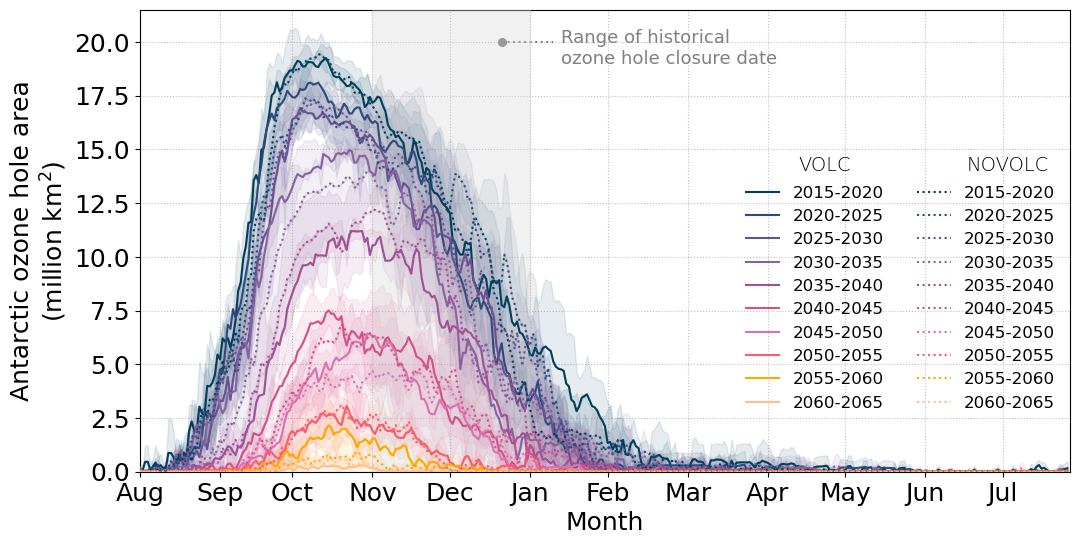

In [15]:
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12,6),dpi=100)
ax.grid(which='major', color='grey', linestyle='dotted', alpha = 0.5)

day = np.arange(0,360,1)
color = ['#003f5c', '#2f4b7c', '#665191', '#86639e', '#a05195',
         '#d45087', '#d973af', '#f95d6a', '#ffa600', '#ffbf86']
labels = ['2015-2020','2020-2025','2025-2030','2030-2035','2035-2040',
          '2040-2045','2045-2050','2050-2055','2055-2060','2060-2065']
month_string = ['Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul']

n = 10

for x in range(n):
    ax.plot(day, mean_ensem[x], label = labels[x], zorder = 10, color = color[x])
    
    ax.fill_between(day, mean_ensem[x], max_ensem[x], color = color[x], alpha = 0.1)

    ax.fill_between(day, mean_ensem[x], min_ensem[x],color = color[x], alpha = 0.1)

for x in range(n):
    ax.plot(day, mean_nv_ensem[x], label = labels[x], linestyle = 'dotted', color = color[x], zorder = 11) 
    
    ax.fill_between(day, mean_nv_ensem[x], max_nv_ensem[x], color = color[x], alpha = 0.1)

    ax.fill_between(day, mean_nv_ensem[x], min_nv_ensem[x], color = color[x], alpha = 0.1) 


ax.axvspan(90,151, color = 'lightgrey', alpha = 0.3, zorder = 4)
ax.text(163, 19, 'Range of historical\nozone hole closure date', color = 'grey',fontsize = 13, zorder = 12)
ax.scatter(140,20, s=30, color='grey')
ax.hlines(20,140,160,color='grey',lw=1.5, ls = 'dotted')

ax.text(255,14, 'VOLC', weight="light", fontsize = 14)
ax.text(320,14, 'NOVOLC', weight="light",fontsize = 14)

#figure adjustment
ax.set_ylabel('Antarctic ozone hole area\n(million km$^2$)', fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.set_xlim(0,360)
ax.set_ylim(0, 21.5)
ax.set_xticklabels(month_string, fontsize = 18)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlabel('Month',fontsize=18)
ax.legend(loc="lower right", fontsize = 12,frameon=False,ncol=2, bbox_to_anchor=(1, 0.1))

fig.savefig('/home/users/mmc70/Notebooks/ACP_ozone_notebooks/for_github/figures_pdf/figure4.pdf')

